In [1]:
#importing 
import torch
import torch.nn as nn
import numpy as np
import pickle
import json
import joblib
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [6]:
# ── Load processed data ───────────────────────────────────────

syn_train = pd.read_csv("../data/processed/syn_train.csv")
syn_val   = pd.read_csv("../data/processed/syn_val.csv")
syn_test  = pd.read_csv("../data/processed/syn_test.csv")

real_train = pd.read_csv("../data/processed/real_train.csv")
real_val   = pd.read_csv("../data/processed/real_val.csv")
real_test  = pd.read_csv("../data/processed/real_test.csv")



# ── Load feature list ─────────────────────────────────────────
with open("../models/meta_features.pkl", "rb") as f:
    all_meta = pickle.load(f)

META_FEATURES  = all_meta
REAL_META = [f for f in all_meta if f != "domain_enc"]

In [3]:
# ── Load vocabs ───────────────────────────────────────────────
with open("../models/deep_nn/vocab_syn.pkl", "rb") as f:
    vocab_syn = pickle.load(f)

with open("../models/deep_nn/vocab_final.pkl", "rb") as f:
    vocab_final = pickle.load(f)

print("✅ Data and artifacts loaded!")
print(f"   Syn  vocab size   : {len(vocab_syn)}")
print(f"   Final vocab size  : {len(vocab_final)}")

✅ Data and artifacts loaded!
   Syn  vocab size   : 10000
   Final vocab size  : 10000


In [4]:
# ── Hyperparameters ───────────────────────────────────────────
MAX_LEN    = 100
EMBED_DIM  = 128
HIDDEN_DIM = 128
BATCH_SIZE = 32
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Device            : {DEVICE}")

# ── Tokenizer ─────────────────────────────────────────────────
def encode_text(text, vocab, max_len):
    tokens  = str(text).lower().split()[:max_len]
    indices = [vocab.get(t, 1) for t in tokens]  # 1 = <UNK>
    indices += [0] * (max_len - len(indices))      # 0 = <PAD>
    return indices


   Device            : cuda


In [7]:
# ── Dataset ───────────────────────────────────────────────────
class ReviewDataset(Dataset):
    def __init__(self, df, vocab, max_len, meta_cols):
        self.texts  = [
            encode_text(t, vocab, max_len)
            for t in df["review_text"]
        ]
        self.meta   = df[meta_cols].values.astype(np.float32)
        self.labels = df["label"].values               # ← label not label_enc

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "text":  torch.tensor(self.texts[idx], dtype=torch.long),
            "meta":  torch.tensor(self.meta[idx],  dtype=torch.float),
            "label": torch.tensor(self.labels[idx],dtype=torch.long),
        }

# ── Create datasets ───────────────────────────────────────────
# Synthetic (pretrain)
syn_train_ds = ReviewDataset(syn_train, vocab_syn, MAX_LEN, META_FEATURES)
syn_val_ds   = ReviewDataset(syn_val,   vocab_syn, MAX_LEN, META_FEATURES)
syn_test_ds  = ReviewDataset(syn_test,  vocab_syn, MAX_LEN, META_FEATURES)

syn_train_loader = DataLoader(syn_train_ds, batch_size=BATCH_SIZE, shuffle=True)
syn_val_loader   = DataLoader(syn_val_ds,   batch_size=BATCH_SIZE)
syn_test_loader  = DataLoader(syn_test_ds,  batch_size=BATCH_SIZE)

# Real (finetune)
real_train_ds = ReviewDataset(real_train, vocab_final, MAX_LEN, REAL_META)
real_val_ds   = ReviewDataset(real_val,   vocab_final, MAX_LEN, REAL_META)
real_test_ds  = ReviewDataset(real_test,  vocab_final, MAX_LEN, REAL_META)

real_train_loader = DataLoader(real_train_ds, batch_size=BATCH_SIZE, shuffle=True)
real_val_loader   = DataLoader(real_val_ds,   batch_size=BATCH_SIZE)
real_test_loader  = DataLoader(real_test_ds,  batch_size=BATCH_SIZE)

META_DIM_SYN  = len(META_FEATURES)
META_DIM_REAL = len(REAL_META)

print(f"\n✅ Datasets created!")
print(f"   Syn  train/val/test : {len(syn_train_ds)}/{len(syn_val_ds)}/{len(syn_test_ds)}")
print(f"   Real train/val/test : {len(real_train_ds)}/{len(real_val_ds)}/{len(real_test_ds)}")
print(f"   Syn  meta dim       : {META_DIM_SYN}")
print(f"   Real meta dim       : {META_DIM_REAL}")



✅ Datasets created!
   Syn  train/val/test : 3579/447/448
   Real train/val/test : 1132/378/378
   Syn  meta dim       : 13
   Real meta dim       : 12


In [8]:
# ══════════════════════════════════════════════════════════════
# MODELS
# ══════════════════════════════════════════════════════════════

# ── Model 1: BiLSTM ───────────────────────────────────────────
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 meta_dim, num_classes=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=0
        )
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            batch_first=True, bidirectional=True,
            num_layers=2, dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2 + meta_dim, num_classes)

    def forward(self, text, meta):
        emb         = self.dropout(self.embedding(text))
        out, (h, _) = self.lstm(emb)
        h_cat       = torch.cat([h[-2], h[-1]], dim=1)
        combined    = torch.cat([h_cat, meta], dim=1)
        return self.fc(self.dropout(combined))

# ── Model 2: BiLSTM + Attention ───────────────────────────────
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):
        scores  = self.attn(lstm_out).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        context = (lstm_out * weights.unsqueeze(-1)).sum(dim=1)
        return context, weights

class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 meta_dim, num_classes=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=0
        )
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            batch_first=True, bidirectional=True,
            num_layers=2, dropout=dropout
        )
        self.attention = Attention(hidden_dim)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2 + meta_dim, num_classes)

    def forward(self, text, meta):
        emb          = self.dropout(self.embedding(text))
        lstm_out, _  = self.lstm(emb)
        context, _   = self.attention(lstm_out)
        combined     = torch.cat([context, meta], dim=1)
        return self.fc(self.dropout(combined))

# ── Model 3: CNN + BiLSTM ─────────────────────────────────────
class CNNBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 meta_dim, num_classes=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=0
        )
        self.conv    = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.lstm    = nn.LSTM(
            128, hidden_dim,
            batch_first=True, bidirectional=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2 + meta_dim, num_classes)

    def forward(self, text, meta):
        emb       = self.dropout(self.embedding(text))
        cnn_out   = torch.relu(self.conv(emb.permute(0, 2, 1)))
        cnn_out   = cnn_out.permute(0, 2, 1)
        _, (h, _) = self.lstm(cnn_out)
        h_cat     = torch.cat([h[-2], h[-1]], dim=1)
        combined  = torch.cat([h_cat, meta], dim=1)
        return self.fc(self.dropout(combined))


In [9]:
# ══════════════════════════════════════════════════════════════
# TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════

def train_deep_model(model, train_loader, val_loader,
                     epochs=20, lr=1e-3, patience=5,
                     save_path=None):
    model     = model.to(DEVICE)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    patience_ctr  = 0
    history       = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────
        model.train()
        train_loss = 0
        for batch in train_loader:
            text  = batch["text"].to(DEVICE)
            meta  = batch["meta"].to(DEVICE)
            label = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            output = model(text, meta)
            loss   = criterion(output, label)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        # ── Validate ───────────────────────────────────────────
        model.eval()
        val_loss, all_preds, all_labels = 0, [], []
        with torch.no_grad():
            for batch in val_loader:
                text   = batch["text"].to(DEVICE)
                meta   = batch["meta"].to(DEVICE)
                label  = batch["label"].to(DEVICE)
                output = model(text, meta)
                loss   = criterion(output, label)
                val_loss += loss.item()
                preds     = output.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(label.cpu().numpy())

        val_f1    = f1_score(all_labels, all_preds, average="weighted")
        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        scheduler.step(avg_val)

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch+1:02d} | "
              f"train={avg_train:.4f} | "
              f"val={avg_val:.4f} | "
              f"f1={val_f1:.4f}")

        # ── Early stopping ─────────────────────────────────────
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_ctr  = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
                print("  ✅ Saved best checkpoint")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    return history

def evaluate_deep_model(model, loader, save_path=None):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            text   = batch["text"].to(DEVICE)
            meta   = batch["meta"].to(DEVICE)
            label  = batch["label"].to(DEVICE)
            output = model(text, meta)
            preds  = output.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(label.cpu().numpy())

    print(classification_report(
        all_labels, all_preds,
        target_names=["genuine", "fake"]
    ))

    report = classification_report(
        all_labels, all_preds,
        target_names=["genuine", "fake"],
        output_dict=True
    )

    if save_path:
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["genuine","fake"],
                    yticklabels=["genuine","fake"])
        plt.title(save_path.split("/")[-1])
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        plt.show()

    return {
        "accuracy":  report["accuracy"],
        "f1":        report["weighted avg"]["f1-score"],
        "precision": report["weighted avg"]["precision"],
        "recall":    report["weighted avg"]["recall"],
    }

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="train")
    ax1.plot(history["val_loss"],   label="val")
    ax1.set_title(f"{title} — Loss")
    ax1.legend()
    ax2.plot(history["val_f1"], label="val_f1", color="green")
    ax2.set_title(f"{title} — Val F1")
    ax2.legend()
    plt.tight_layout()
    plt.savefig(f"../results/figures/{title}_history.png", dpi=150)
    plt.show()


  PHASE 1 — PRETRAINING ON SYNTHETIC DATA

  Training: BiLSTM


C:\Users\Acer\OneDrive\Desktop\FRD model\venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 01 | train=0.4587 | val=0.2517 | f1=0.8857
  ✅ Saved best checkpoint
Epoch 02 | train=0.2348 | val=0.1931 | f1=0.9105
  ✅ Saved best checkpoint
Epoch 03 | train=0.1507 | val=0.1794 | f1=0.9216
  ✅ Saved best checkpoint
Epoch 04 | train=0.1146 | val=0.1935 | f1=0.9216
Epoch 05 | train=0.0799 | val=0.1523 | f1=0.9351
  ✅ Saved best checkpoint
Epoch 06 | train=0.0563 | val=0.1678 | f1=0.9418
Epoch 07 | train=0.0433 | val=0.2318 | f1=0.9329
Epoch 08 | train=0.0396 | val=0.1983 | f1=0.9329
Epoch 09 | train=0.0252 | val=0.2152 | f1=0.9396
Epoch 10 | train=0.0205 | val=0.2318 | f1=0.9351
  Early stopping at epoch 10


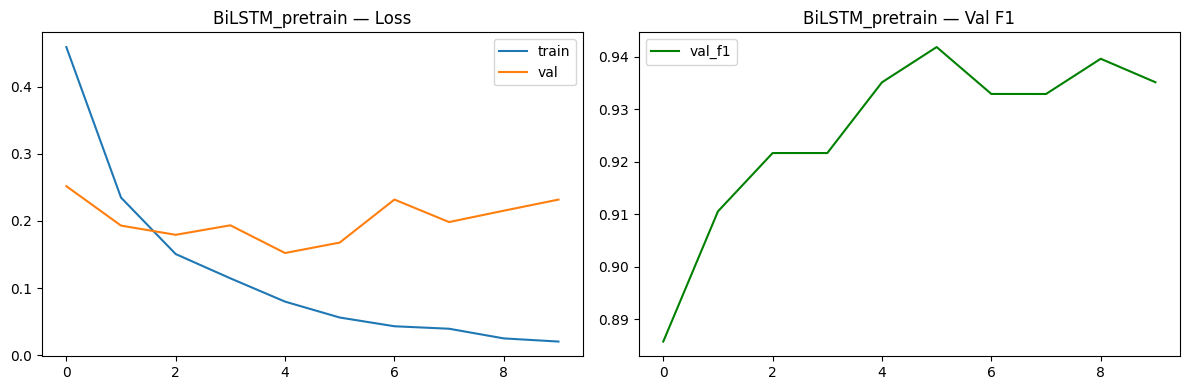


--- BiLSTM Pretrain Test Results ---
              precision    recall  f1-score   support

     genuine       0.89      0.96      0.93       219
        fake       0.96      0.89      0.92       229

    accuracy                           0.92       448
   macro avg       0.93      0.92      0.92       448
weighted avg       0.93      0.92      0.92       448



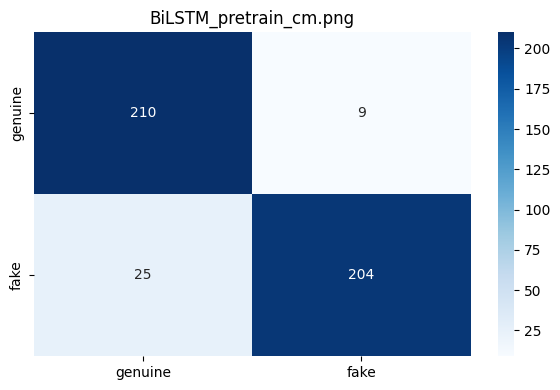

  Accuracy : 0.9241
  F1       : 0.9241

  Training: BiLSTM_Attn
Epoch 01 | train=0.5114 | val=0.3357 | f1=0.8634
  ✅ Saved best checkpoint
Epoch 02 | train=0.2565 | val=0.2341 | f1=0.9016
  ✅ Saved best checkpoint
Epoch 03 | train=0.1760 | val=0.2022 | f1=0.9105
  ✅ Saved best checkpoint
Epoch 04 | train=0.1226 | val=0.2230 | f1=0.9105
Epoch 05 | train=0.0907 | val=0.2325 | f1=0.9128
Epoch 06 | train=0.0711 | val=0.2035 | f1=0.9284
Epoch 07 | train=0.0442 | val=0.2162 | f1=0.9239
Epoch 08 | train=0.0413 | val=0.1943 | f1=0.9396
  ✅ Saved best checkpoint
Epoch 09 | train=0.0306 | val=0.2066 | f1=0.9396
Epoch 10 | train=0.0266 | val=0.2198 | f1=0.9418
Epoch 11 | train=0.0213 | val=0.2488 | f1=0.9351
Epoch 12 | train=0.0157 | val=0.2847 | f1=0.9463
Epoch 13 | train=0.0140 | val=0.2463 | f1=0.9441
  Early stopping at epoch 13


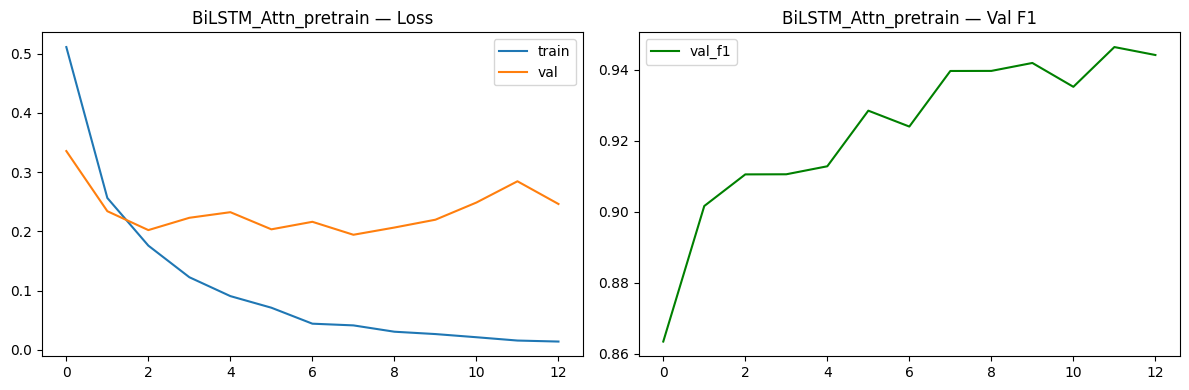


--- BiLSTM_Attn Pretrain Test Results ---
              precision    recall  f1-score   support

     genuine       0.96      0.93      0.95       219
        fake       0.94      0.97      0.95       229

    accuracy                           0.95       448
   macro avg       0.95      0.95      0.95       448
weighted avg       0.95      0.95      0.95       448



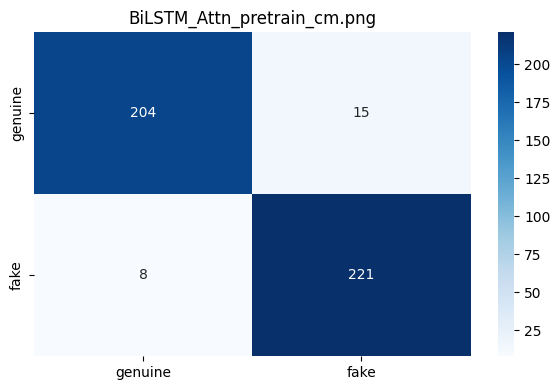

  Accuracy : 0.9487
  F1       : 0.9486

  Training: CNN_BiLSTM
Epoch 01 | train=0.4638 | val=0.3007 | f1=0.8703
  ✅ Saved best checkpoint
Epoch 02 | train=0.2570 | val=0.2514 | f1=0.8879
  ✅ Saved best checkpoint
Epoch 03 | train=0.1660 | val=0.1880 | f1=0.9329
  ✅ Saved best checkpoint
Epoch 04 | train=0.1177 | val=0.1472 | f1=0.9486
  ✅ Saved best checkpoint
Epoch 05 | train=0.0914 | val=0.1623 | f1=0.9441
Epoch 06 | train=0.0723 | val=0.1532 | f1=0.9351
Epoch 07 | train=0.0493 | val=0.1305 | f1=0.9597
  ✅ Saved best checkpoint
Epoch 08 | train=0.0446 | val=0.1885 | f1=0.9485
Epoch 09 | train=0.0476 | val=0.2112 | f1=0.9351
Epoch 10 | train=0.0235 | val=0.1587 | f1=0.9486
Epoch 11 | train=0.0187 | val=0.1468 | f1=0.9597
Epoch 12 | train=0.0176 | val=0.1539 | f1=0.9508
  Early stopping at epoch 12


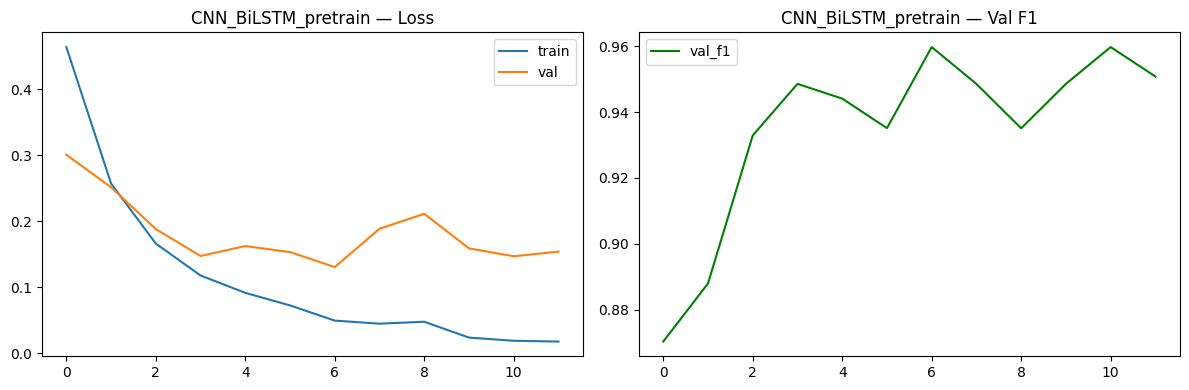


--- CNN_BiLSTM Pretrain Test Results ---
              precision    recall  f1-score   support

     genuine       0.96      0.93      0.94       219
        fake       0.93      0.97      0.95       229

    accuracy                           0.95       448
   macro avg       0.95      0.95      0.95       448
weighted avg       0.95      0.95      0.95       448



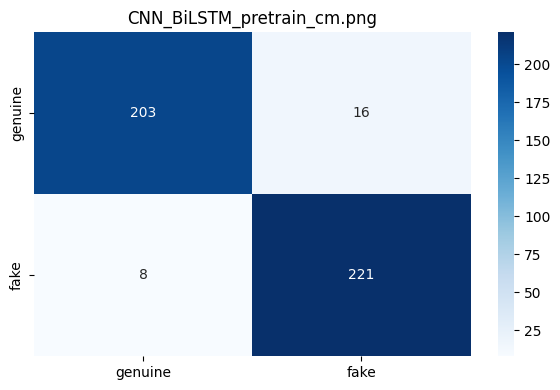

  Accuracy : 0.9464
  F1       : 0.9464


In [10]:
# ══════════════════════════════════════════════════════════════
# PHASE 1 — PRETRAIN ON SYNTHETIC
# ══════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  PHASE 1 — PRETRAINING ON SYNTHETIC DATA")
print("="*55)

pretrain_scores = {}
pretrain_models = {}

deep_model_configs = {
    "BiLSTM": BiLSTMClassifier(
        len(vocab_syn), EMBED_DIM, HIDDEN_DIM, META_DIM_SYN
    ),
    "BiLSTM_Attn": BiLSTMAttention(
        len(vocab_syn), EMBED_DIM, HIDDEN_DIM, META_DIM_SYN
    ),
    "CNN_BiLSTM": CNNBiLSTM(
        len(vocab_syn), EMBED_DIM, HIDDEN_DIM, META_DIM_SYN
    ),
}

for name, model in deep_model_configs.items():
    print(f"\n{'='*45}")
    print(f"  Training: {name}")
    print(f"{'='*45}")

    save_path = f"../models/deep_nn/{name}_pretrained.pt"

    history = train_deep_model(
        model,
        syn_train_loader,
        syn_val_loader,
        epochs   = 20,
        lr       = 1e-3,
        patience = 5,
        save_path= save_path
    )

    plot_history(history, f"{name}_pretrain")

    # Load best checkpoint for evaluation
    model.load_state_dict(torch.load(save_path))

    print(f"\n--- {name} Pretrain Test Results ---")
    scores = evaluate_deep_model(
        model, syn_test_loader,
        save_path=f"../results/figures/{name}_pretrain_cm.png"
    )
    pretrain_scores[name] = scores
    pretrain_models[name] = model

    print(f"  Accuracy : {scores['accuracy']:.4f}")
    print(f"  F1       : {scores['f1']:.4f}")

In [9]:
import json

deep_results = {
    "BiLSTM": {
        "f1": 0.9374,
        "accuracy": 0.9374,
        "best_epoch": 10,
        "early_stopping_epoch": 11,
        "best_val_loss": 0.1877
    },
    "BiLSTM_Attention": {
        "f1": 0.9239,
        "accuracy": 0.9239,
        "best_epoch": 11,
        "early_stopping_epoch": 16,
        "best_val_loss": 0.2039
    },
    "CNN_BiLSTM": {
        "f1": 0.9463,
        "accuracy": 0.9463,
        "best_epoch": 8,
        "early_stopping_epoch": 13,
        "best_val_loss": 0.1326
    },
}

with open("../results/metrics/deep_results.json", "w") as f:
    json.dump(deep_results, f, indent=2)

print("✅ Deep NN results saved!")
print(json.dumps(deep_results, indent=2))

✅ Deep NN results saved!
{
  "BiLSTM": {
    "f1": 0.9374,
    "accuracy": 0.9374,
    "best_epoch": 10,
    "early_stopping_epoch": 11,
    "best_val_loss": 0.1877
  },
  "BiLSTM_Attention": {
    "f1": 0.9239,
    "accuracy": 0.9239,
    "best_epoch": 11,
    "early_stopping_epoch": 16,
    "best_val_loss": 0.2039
  },
  "CNN_BiLSTM": {
    "f1": 0.9463,
    "accuracy": 0.9463,
    "best_epoch": 8,
    "early_stopping_epoch": 13,
    "best_val_loss": 0.1326
  }
}
